# Grouped Whisker Chart

In [ ]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleaning the data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])


In [ ]:
# selecting the Data Analyst job in india
DE_US_df = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()

# now removing the NaN values from salary_year_avg
DE_US_df = DE_US_df.dropna(subset=['salary_year_avg'])

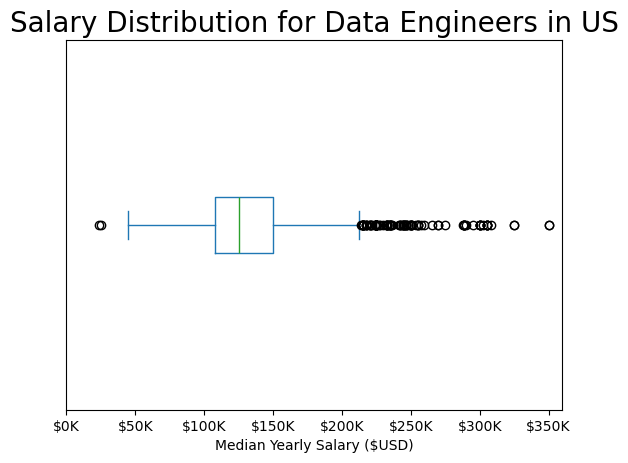

In [ ]:
import matplotlib.ticker as mticker
# now creating the whisker chart
DE_US_df['salary_year_avg'].plot(kind="box",vert=False)

# formatting the labels
plt.xlabel('Median Yearly Salary ($USD)')
plt.title('Salary Distribution for Data Engineers in US', fontsize=20)
plt.yticks([])
plt.xlim(0,360000)


plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()